# Random Forest
Author: Michael Meier

Build a random forest and train it on the tf_bind_8 dataset.

In [1]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

SEED = 42

2025-12-01 18:10:25.018554: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


#### experiments

In [2]:
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')

x = df.iloc[:, :-2].values
# one hot encode the sequences
x_tensor = tf.one_hot(x, depth=4)
x = x_tensor.numpy()

y = df.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=SEED)

print(f'Training samples: {x_train.shape[0]}')
print(f'Testing samples: {x_test.shape[0]}')

Training samples: 52633
Testing samples: 13159


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state = SEED)

# flatten training data
flat_shape = x_train.shape[1] * x_train.shape[2]
x_reshaped = x_train.reshape(x_train.shape[0], flat_shape)

rf.fit(x_reshaped, y_train)

# Evaluation

x_test = x_test.reshape(x_test.shape[0], flat_shape)

y_prediction = rf.predict(x_test)
r2 = r2_score(y_test, y_prediction)
mse = mean_squared_error(y_test, y_prediction)

print(f'R2 Score: {r2}; MSE: {mse}')

In [ ]:
sample = [0,0,0,0,0,0,0,0]
prediction = rf.predict([sample])
print(f'Prediction for sample {sample}: {prediction}')

In [ ]:
import oracle
history = oracle.train_oracle(x, y)

# Plot training history
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## 1. Initialization

In [16]:
# load random part of the data for RF training
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')
df = df.sample(frac=0.3, random_state=SEED)  # use 30% of the data
x = df.iloc[:, :-2].values
y = df.iloc[:, -1].values


# one hot encode the sequences
x_tensor = tf.one_hot(x, depth=4)
x = x_tensor.numpy()

X_flattened = x.reshape((x.shape[0], -1))
#print(X_flattened)

train_x_rf, x_test, train_y_rf, y_test = train_test_split(X_flattened, y, test_size=0.1, random_state=SEED)


# initialize random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
def train_rf(rf, train_x, train_y):
    rf.fit(train_x, train_y)
    # evaluate RF
    y_pred_rf = rf.predict(x_test)
    r2_rf = r2_score(y_test, y_pred_rf)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    print(f'RF R2 Score: {r2_rf}; MSE: {mse_rf}')
train_rf(rf, train_x_rf, train_y_rf)


RF R2 Score: 0.681765939661908; MSE: 0.010432543533573627


In [ ]:
import SingleMutantWalker as smw
import keras
from keras.models import load_model
from keras import layers
from keras.metrics import mean_squared_error # Import the metric explicitly
from keras.losses import MeanSquaredError # Import the loss explicitly

custom_objects = {
        'mse': mean_squared_error,
        'mean_squared_error': mean_squared_error,
        
    }
    
oracle_model = load_model('oracle_model.h5', custom_objects=custom_objects)
print("\nModel successfully loaded using custom_objects.")
# Initialize Single Mutant Walker
smw = smw.SMW(nucleotides = [0, 1, 2, 3])
# Init fitness function:
fitness_function = rf.predict

timesteps = 20
gen_sequences_length = 10
mutation_steps = 5

initial_sequence = df.sample(n=1, random_state=SEED).iloc[:, :-2].values[0]


df_sequences = pd.DataFrame(columns=['sequence', 'rf_fitness', 'oracle_prediction', 'timestep'])

for t in range(timesteps):
    generated_sequences = []
    for n in range(gen_sequences_length):
        
        generated = smw.walk(initial_sequence, mutation_steps, fitness_function)
        generated_sequences.extend(generated)
        if (n+1) % 200 == 0:
            print(f'Timestep {t+1}, generated {n+1} sequences')

    # Evaluate generated sequences with oracle
    gen_x = []
    gen_y = []
    # Build df with sequence fitness from RF and oracle predictions
    
    for seq in generated_sequences:
        seq_fitness = seq[1]
        sequence = seq[0]
        oracle_prediction = oracle_model.predict(tf.one_hot([sequence], depth=4).numpy())
        gen_x.append(sequence)
        gen_y.append(oracle_prediction[0][0])
        
        new_row_data = {'sequence': sequence,
                'rf_fitness': seq_fitness[0] if seq_fitness != 0 else 0,
                'oracle_prediction': oracle_prediction[0][0], 'timestep': t+1}
        new_row_df = pd.DataFrame([new_row_data])
        df_sequences = pd.concat([df_sequences, new_row_df], ignore_index=True)

        #print(f'Sequence: {sequence}, RF fitness: {seq_fitness}, Oracle prediction: {oracle_prediction[0][0]}')


    #retrain RF with generated sequences
    gen_x_onehot = tf.one_hot(gen_x, depth=4).numpy()
    gen_x_flattened = gen_x_onehot.reshape(gen_x_onehot.shape[0], 32)
    train_rf(rf, gen_x_flattened, np.array(gen_y))
    # print training results
    print(f'After timestep {t+1}, retrained RF with {len(gen_x)} generated sequences.')



Model successfully loaded using custom_objects.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

/var/folders/g0/0kyrd62j6c51vljztrhmg4mc0000gn/T/ipykernel_11269/2431347775.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sequences = pd.concat([df_sequences, new_row_df], ignore_index=True)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99

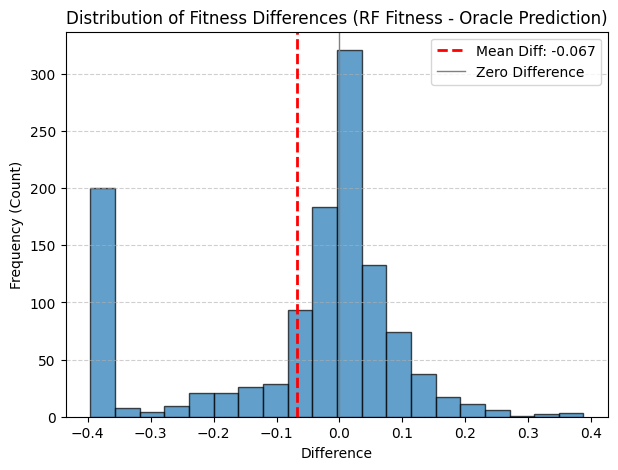

In [39]:
df_sequences['difference'] = df_sequences['rf_fitness'] - df_sequences['oracle_prediction']

plt.figure(figsize=(7, 5))
plt.hist(df_sequences['difference'], bins=20, edgecolor='black', alpha=0.7)

mean_diff = df_sequences['difference'].mean()
plt.axvline(mean_diff, color='r', linestyle='dashed', linewidth=2, label=f'Mean Diff: {mean_diff:.3f}')
plt.axvline(0, color='gray', linestyle='-', linewidth=1, label='Zero Difference')

plt.title('Distribution of Fitness Differences (RF Fitness - Oracle Prediction)')
plt.xlabel('Difference')
plt.ylabel('Frequency (Count)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


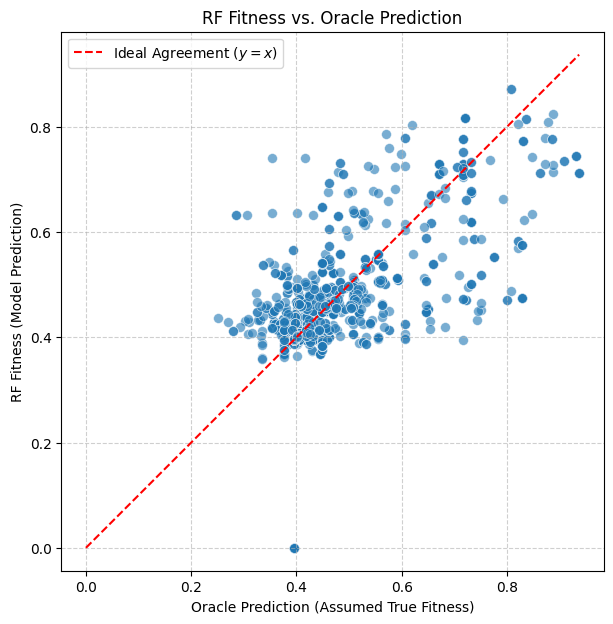

In [40]:
plt.figure(figsize=(7, 7))
plt.scatter(df_sequences['oracle_prediction'], df_sequences['rf_fitness'], alpha=0.6, s=50, edgecolors='w', linewidths=0.5)

# Add the y=x line (ideal agreement)
min_val = min(df_sequences['oracle_prediction'].min(), df_sequences['rf_fitness'].min())
max_val = max(df_sequences['oracle_prediction'].max(), df_sequences['rf_fitness'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Agreement ($y=x$)')

plt.title('RF Fitness vs. Oracle Prediction')
plt.xlabel('Oracle Prediction (Assumed True Fitness)')
plt.ylabel('RF Fitness (Model Prediction)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal') # Ensures the plot is square for accurate visual comparison
plt.show()


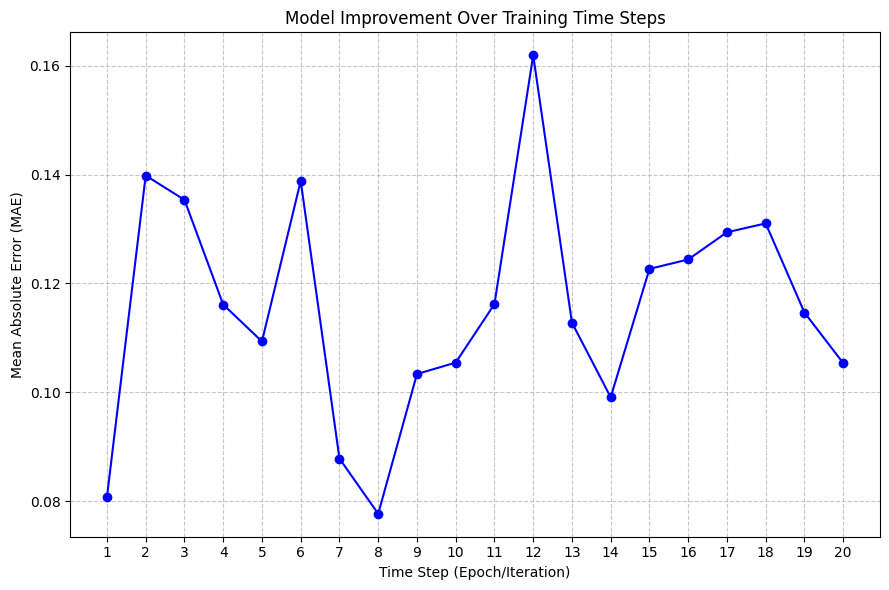

In [44]:
# Calculate the Absolute Error
df_sequences['absolute_error'] = np.abs(df_sequences['rf_fitness'] - df_sequences['oracle_prediction'])

# Group by timestep and calculate the average Absolute Error (MAE)
improvement_data = df_sequences.groupby('timestep')['absolute_error'].mean().reset_index()

# Plot the data
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.plot(improvement_data['timestep'], improvement_data['absolute_error'], 
         marker='o', linestyle='-', color='b')

plt.title('Model Improvement Over Training Time Steps')
plt.xlabel('Time Step (Epoch/Iteration)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(improvement_data['timestep'])
plt.tight_layout()
plt.show()